In [36]:
# jupyter notebook 전체화면으로 변경  
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
import seaborn as sns

from my_funs import *
from sklearn import metrics
from matplotlib import gridspec
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

dongs = ['강남동', '교  동', '근화동', '남  면', '남산면', '동  면', '동내면', '동산면', '북산면',
       '사북면', '서  면', '석사동', '소양동', '신동면', '신북읍', '신사우동', '약사명동', '조운동',
       '퇴계동', '효자1동', '후평1동']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [34]:
def get_val_dataloader(training , data , time_idx):
    batch_size= 32    
    # test_data를 계속 append 하는 식으로 새생성
    test_data = data[data['time_idx'] < time_idx]
    validation = TimeSeriesDataSet.from_dataset(training, test_data, predict=True, stop_randomization=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=1)
    return val_dataloader

def confusion_matrix_plot(training, tft ,data, dong , title):
    # 원본 함수 
    fig = plt.figure(figsize=(25, 7))
    gs = gridspec.GridSpec(nrows=2, # row 몇 개 
                           ncols=2, # col 몇 개 
                           height_ratios=[1,1], 
                           width_ratios=[5,1]
                          )

    gs.update(wspace=0.025, hspace=0.2)
    ax0 = plt.subplot(gs[: , 0])
    ax1 = plt.subplot(gs[1,1])
    ax2 = plt.subplot(gs[0,1])

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.axis('off')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.axis('off')

    ax0.set_title(f'{dong}_plot {title}' , fontsize = 20)
    ax2.set_title('confusion_matrix', fontsize = 20)
    ax1.set_title('recall & precision , MAE', fontsize = 20)

    # 원하는 동 선택이후  예측할려는 기간의 count와 index(REG_DTIME)를 가져옴
    df = data[data['h_dong']==dong]
    df_index = df[df['time_idx'] > 24* 7 -1]['REG_DTIME']
    org_count = df[df['time_idx'] > 24* 7 -1 ]['count']

    predition5= np.array([])
    for i in range(1,52):
        # 1년(8760) + 하루(24) * idx를 이용해서 하루씩 append하는 식으로 prediction 진행
        val_data = get_val_dataloader(training ,data, 24*7 + 24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        # dong의 문자열 표현을 tft.prediction을 하기 위해서 숫자로 변경
        idx = idx_df[idx_df['h_dong'] == dong].index[0]
        # 90퍼 값만 사용하기 위해서 [idx, : , 5]과 같이 슬라이싱
        predition5 = np.concatenate([predition5,pred['prediction'][idx, : , 5]])
    
    # tft가 예측한 값 plot(rounding 적용 X)
    ax0.plot(df_index,predition5 , label = 'preidction' , alpha=0.4)

    # 원래의 발생 빈도 값을 round 적용 및 T/F 화
    org_count = org_count.to_numpy().round()
    org_count = np.logical_not(org_count < 1)
    # prediction 값을 round 적용 및 T/F 화
    predition5 = predition5.round()
    predition5 = np.logical_not(predition5 < 1)
    
    # round된 두 값을 plot로 시각화
    ax0.plot(df_index,org_count , label = 'orginal target' , alpha=1)
    ax0.plot(df_index,predition5 ,label = '90% prediction round', alpha= 0.6, linestyle='--')
    ax0.legend()

    # confusion martix 계산 및 heatmap 시각화
    tn, fp, fn, tp = metrics.confusion_matrix(org_count,predition5).ravel()

    c_mat = np.array([[tp , fp],[fn , tn]])
    ax1 = sns.heatmap(c_mat, annot=True, cbar = False, fmt='g',cmap='Blues')

    f1_score = metrics.f1_score(org_count,predition5)
    recall = metrics.recall_score(org_count,predition5)
    precision = metrics.precision_score(org_count,predition5)
    MAE = abs(recall - precision)

    ax2.text(0.1, 3.1 , f'f1 score  {f1_score : 4f}' , fontsize=25)
    ax2.text(0.1, 3.4 , f'recall      {recall : 4f}' , fontsize=25)
    ax2.text(0.1, 3.7 , f'precision {precision : 4f}' , fontsize=25)
    ax2.text(0.1, 4.1 , f'MAE        {MAE : 4f}' , fontsize=25)
    
def dong_f1(training, tft ,data, dong):
    df = data[data['h_dong']==dong]
    df_index = df[df['time_idx'] > 24* 7 -1]['REG_DTIME']
    org_count = df[df['time_idx'] > 24* 7 -1 ]['count']

    predition5= np.array([])
    for i in range(1,52):
        # 1년(8760) + 하루(24) * idx를 이용해서 하루씩 append하는 식으로 prediction 진행
        val_data = get_val_dataloader(training ,data, 24*7 + 24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        # dong의 문자열 표현을 tft.prediction을 하기 위해서 숫자로 변경
        idx = idx_df[idx_df['h_dong'] == dong].index[0]
        # 90퍼 값만 사용하기 위해서 [idx, : , 5]과 같이 슬라이싱
        predition5 = np.concatenate([predition5,pred['prediction'][idx, : , 5]])
    
    # 원래의 발생 빈도 값을 round 적용 및 T/F 화
    org_count = org_count.to_numpy().round()
    org_count = np.logical_not(org_count < 1)
    # prediction 값을 round 적용 및 T/F 화
    predition5 = predition5.round()
    predition5 = np.logical_not(predition5 < 1)
    return metrics.f1_score(org_count,predition5)
    
def dong_f1_all(training , tft ,data):
    val_data = get_val_dataloader(training ,data, 24*7 + 24)
    pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
    predictions = pred['prediction'][:, : , 5]

    for i in range(2,52):
        val_data = get_val_dataloader(training ,data, 24*7 + 24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        predictions = torch.cat([predictions ,pred['prediction'][:, : , 5]], dim=1) 
    predictions = predictions.reshape(-1,1)

    org_df = data[data['time_idx'] > 24*7 -1]
    org_count = []
    for dong in dongs:
        org_count.extend(org_df[org_df['h_dong'] == dong]['count'].to_list())

        
    org_count = np.array(org_count).round()
    org_count = np.logical_not(org_count < 1)
    # prediction 값을 round 적용 및 T/F 화
    predictions = predictions.round()
    predictions = np.logical_not(predictions < 1)
    return metrics.f1_score(org_count,predictions)
    
    
def get_f1(training, tft ,data):
    f1_df = pd.DataFrame(columns = ['h_dong' , 'f1_score'])
    for idx, dong in enumerate(dongs):
        print(f'{dong} is processing')
        f1_df.loc[idx,'h_dong'] = dong
        f1_df.loc[idx,'f1_score'] = dong_f1(training, tft ,data, dong)
    return f1_df.sort_values(by='f1_score' , ascending=False)

In [18]:
# best trial model ckpt
train_data = data_processing('../../train.csv' , 0.4)
test_data = data_processing('../../test.csv' , 0.4)
training = get_training(train_data,24, 24*7)
model_ckpt = 'logger/lightning_logs/version_0/checkpoints/epoch=99-step=2000.ckpt'
tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)
 

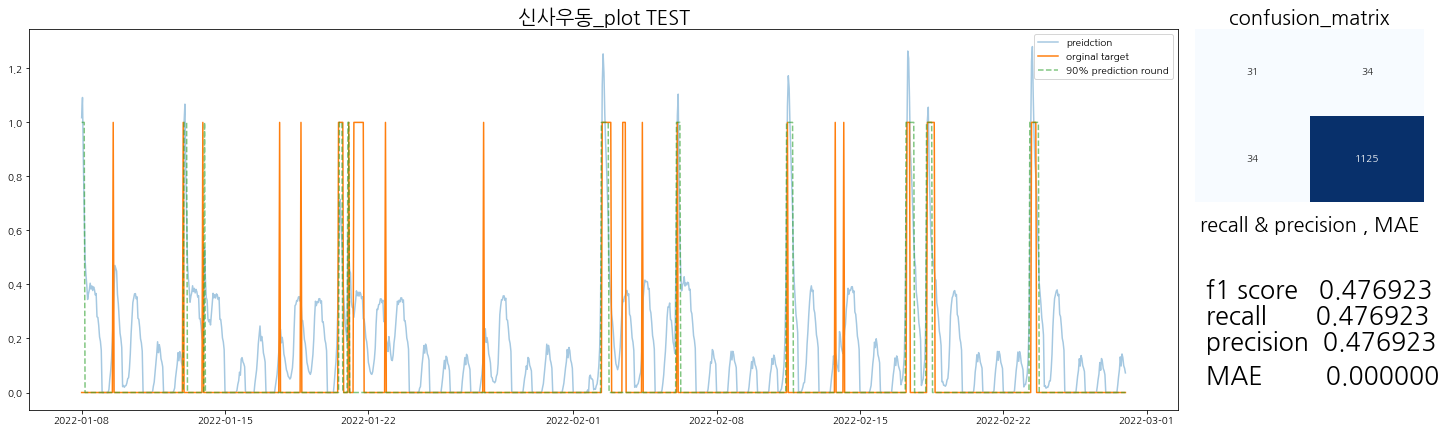

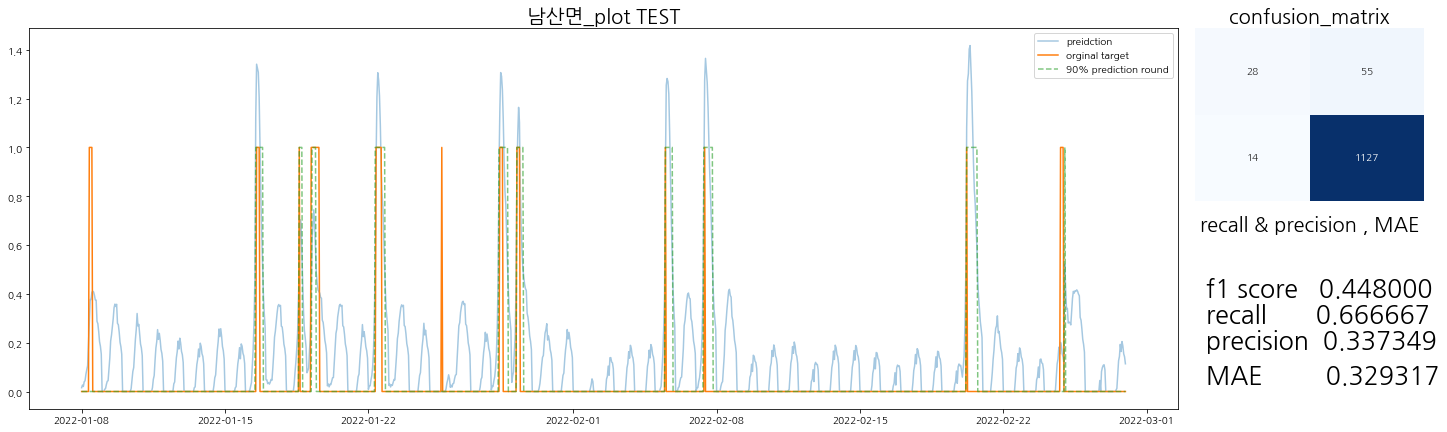

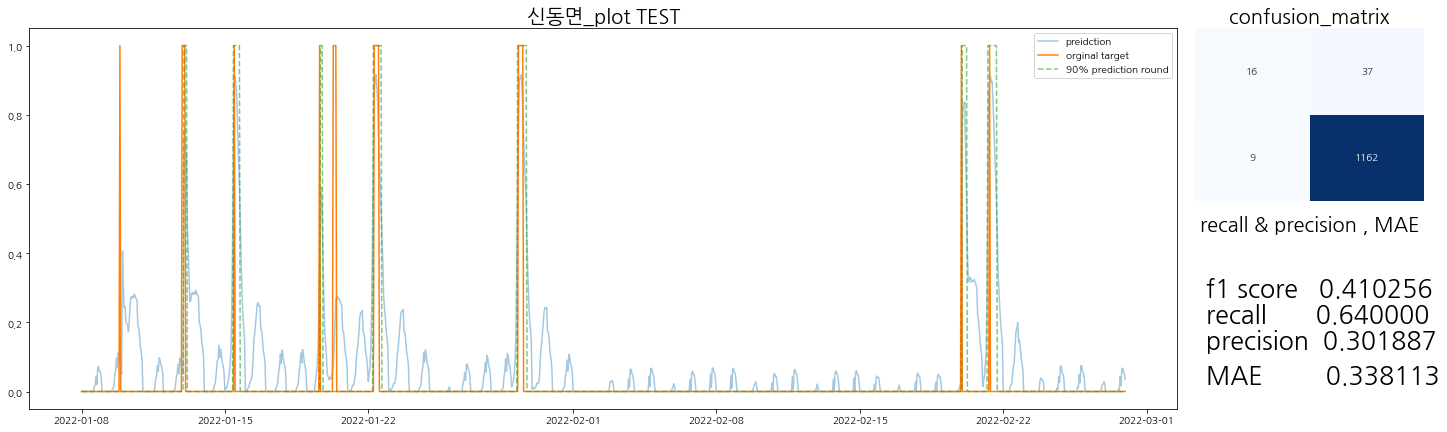

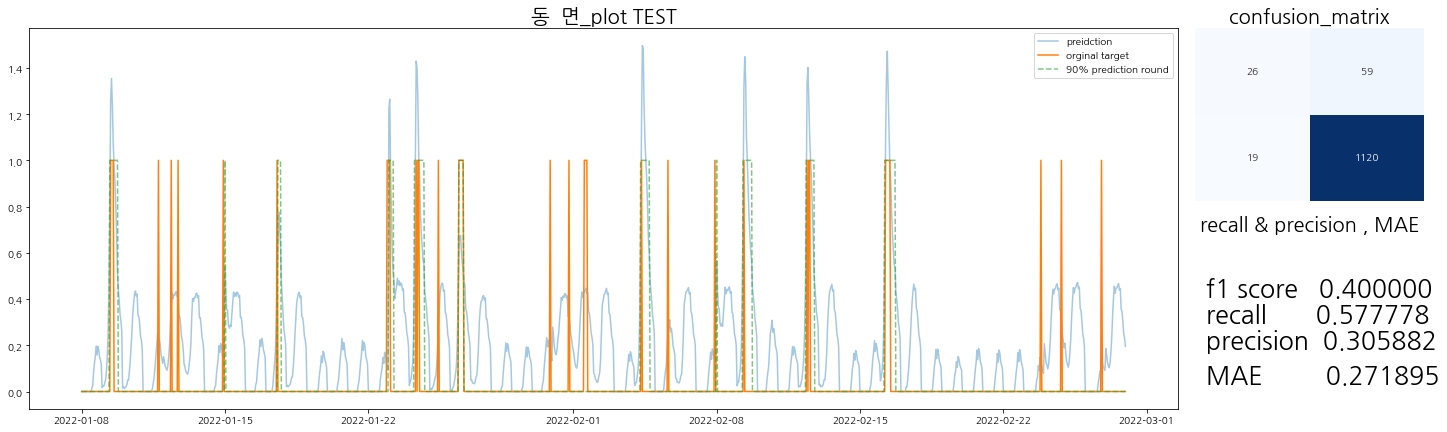

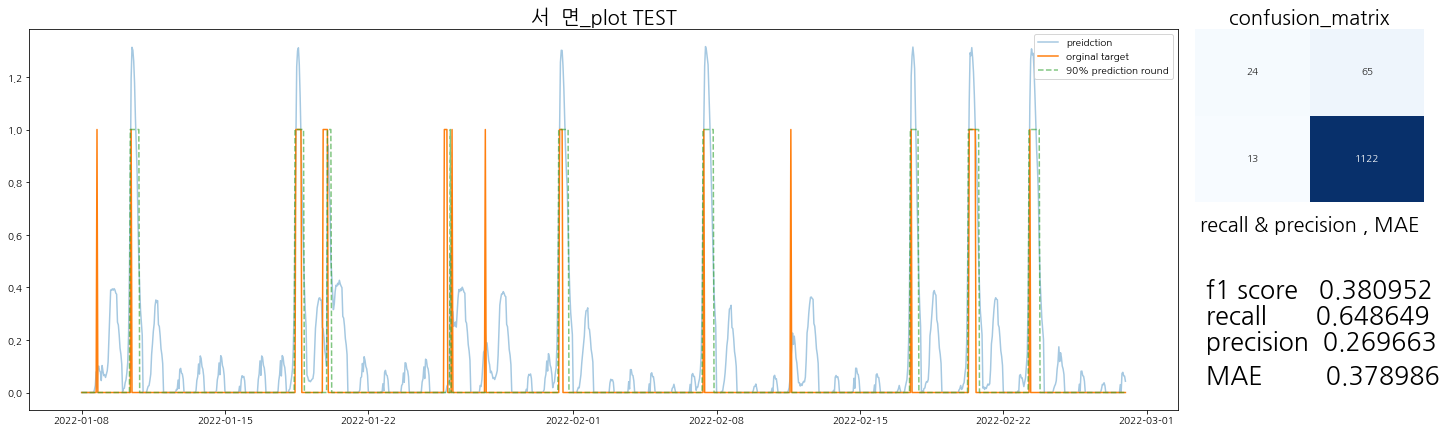

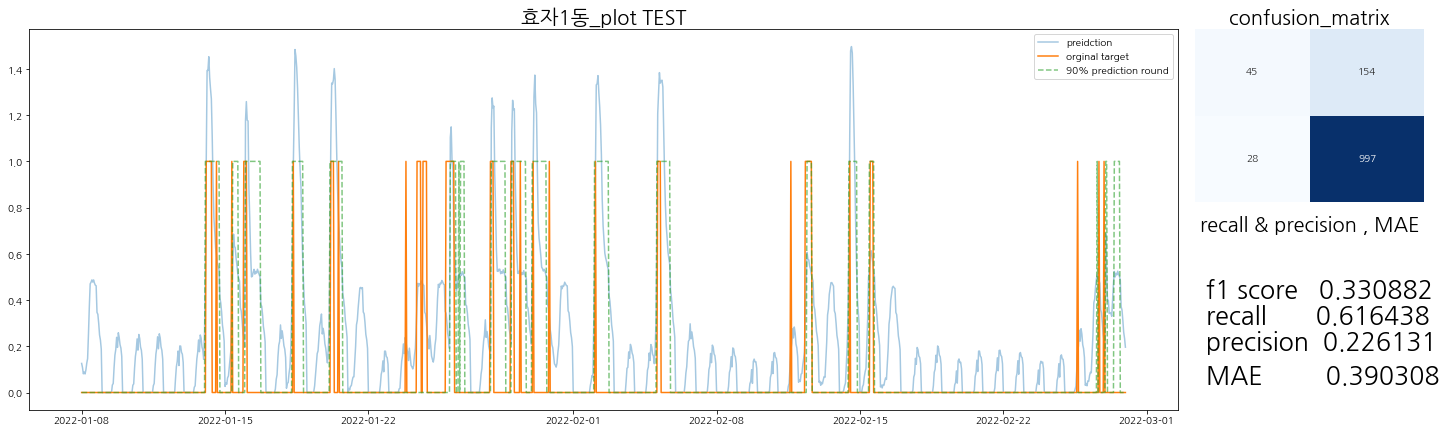

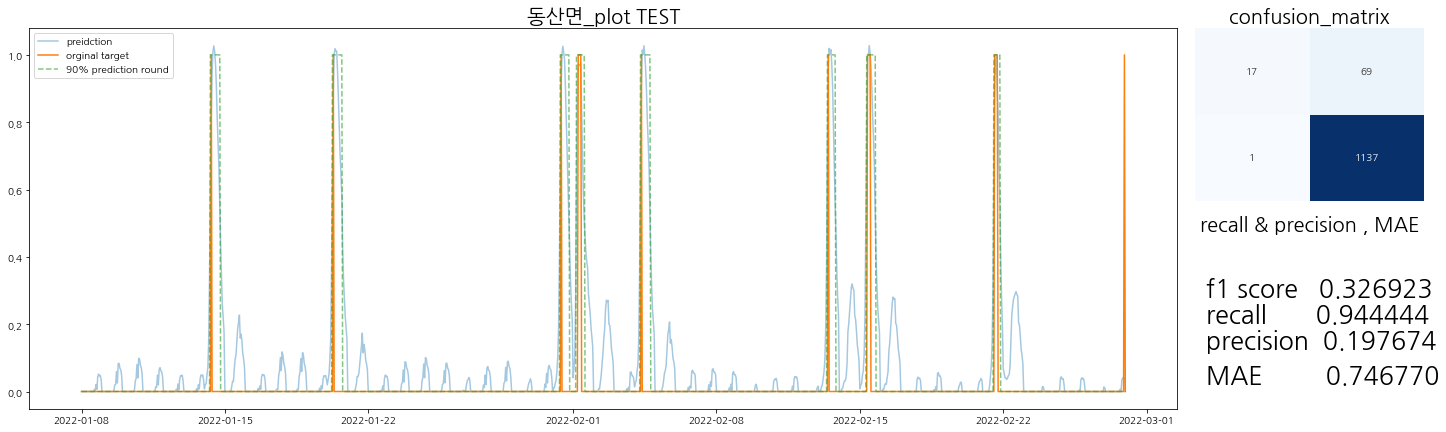

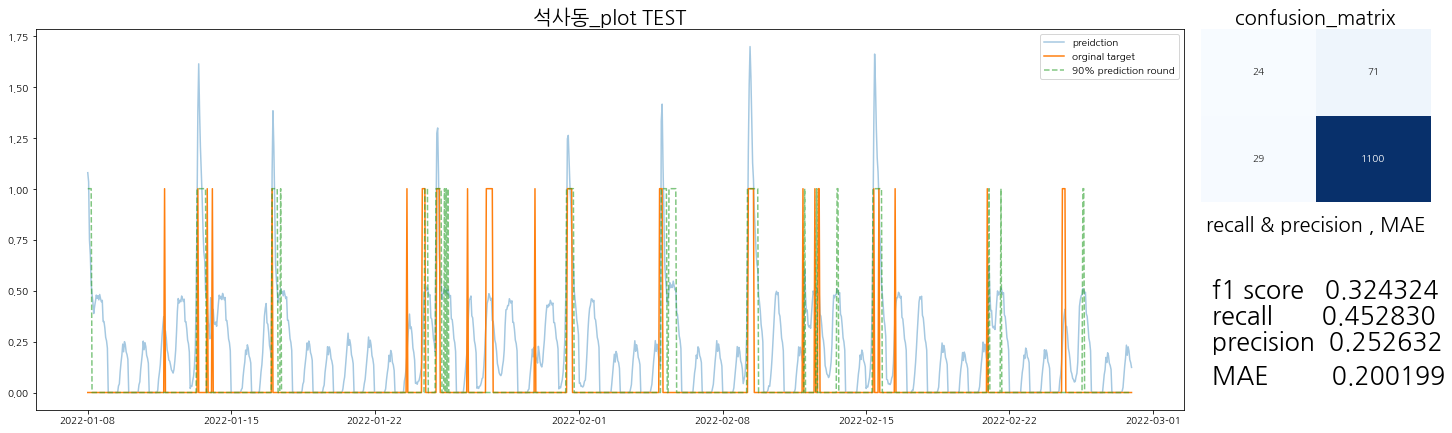

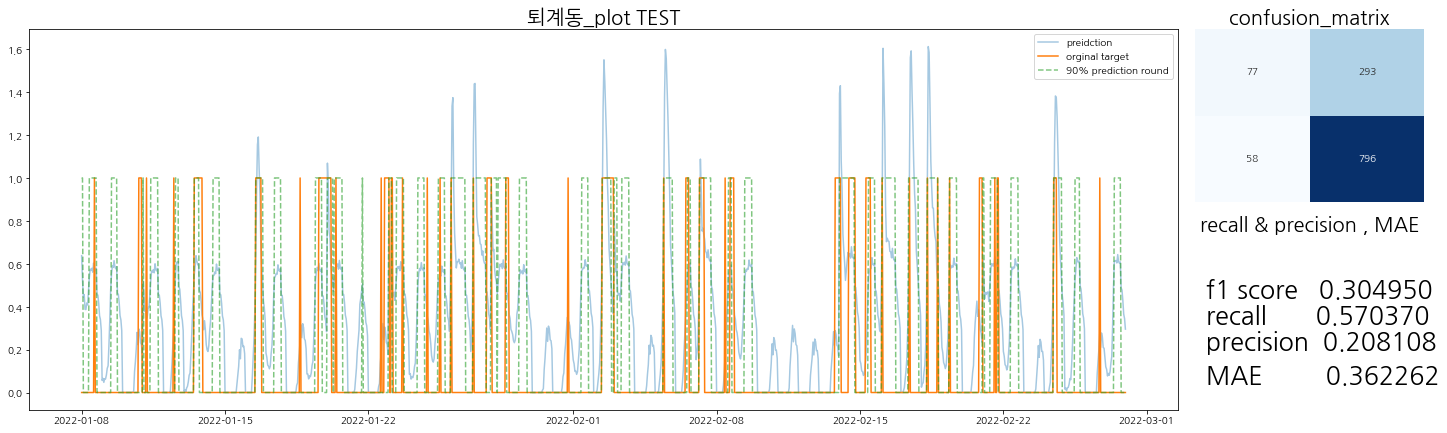

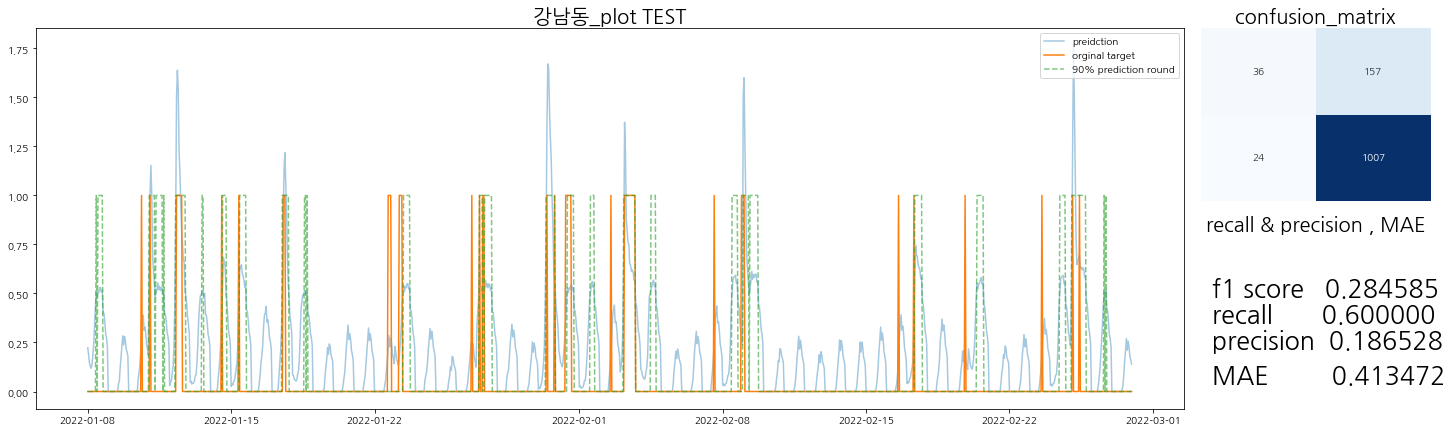

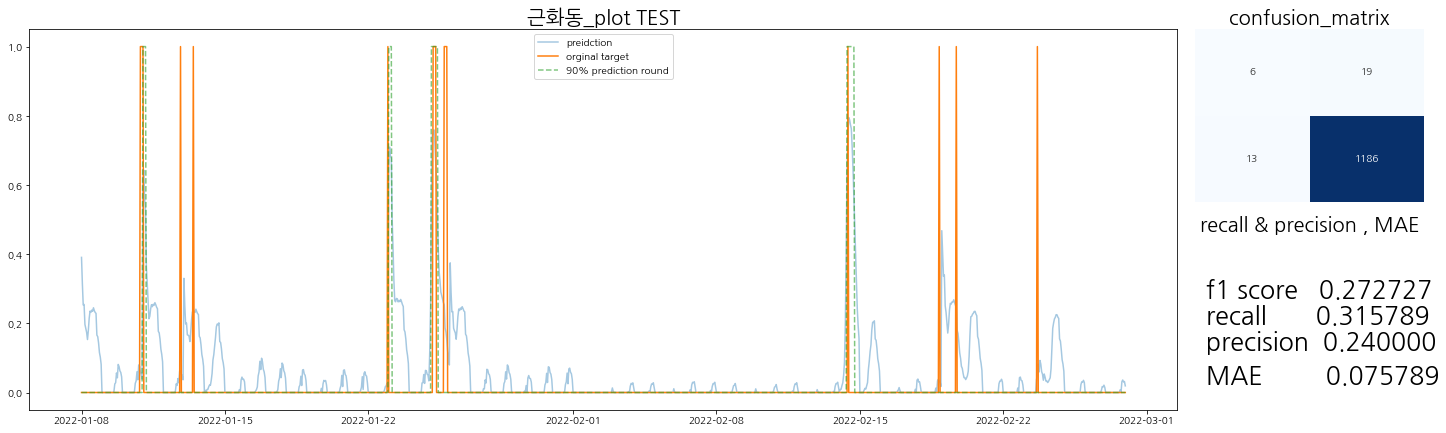

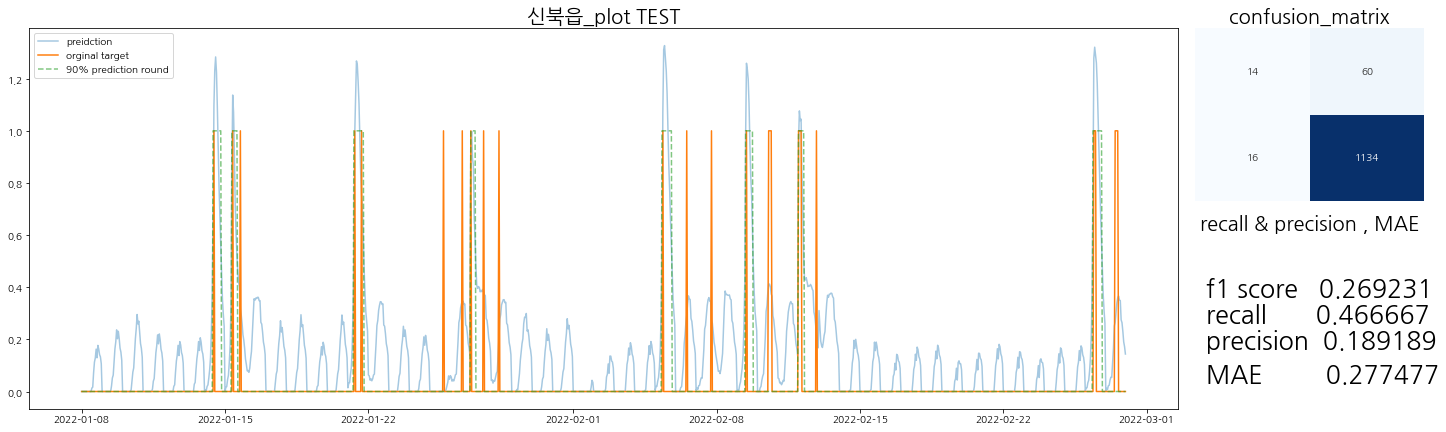

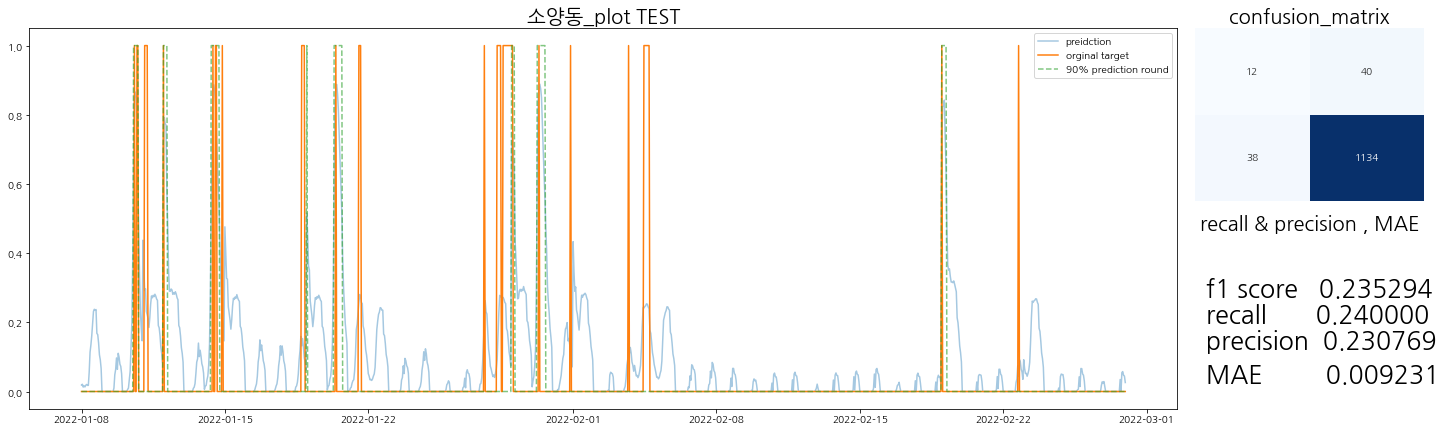

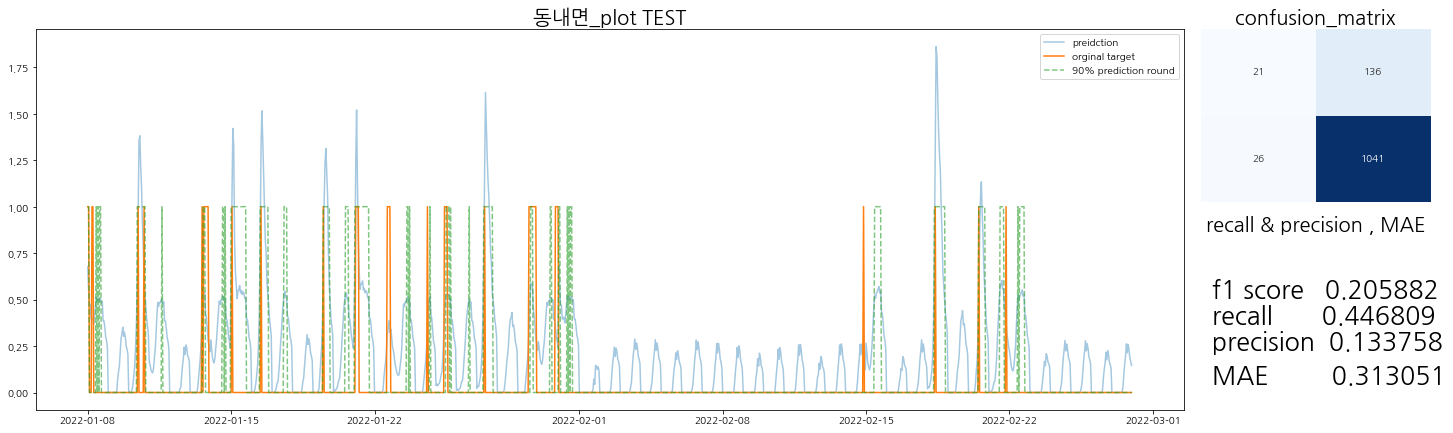

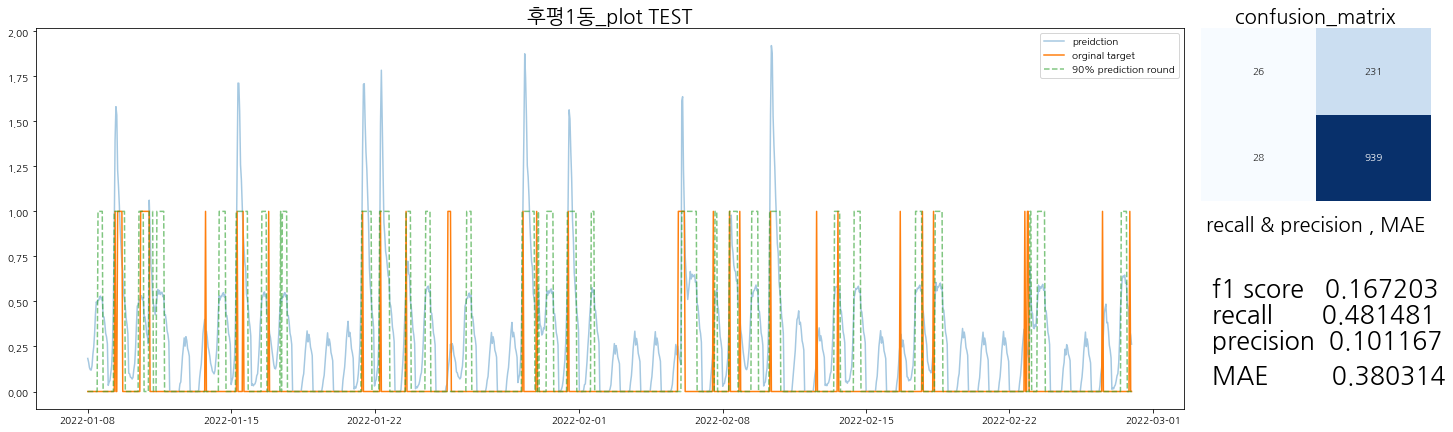

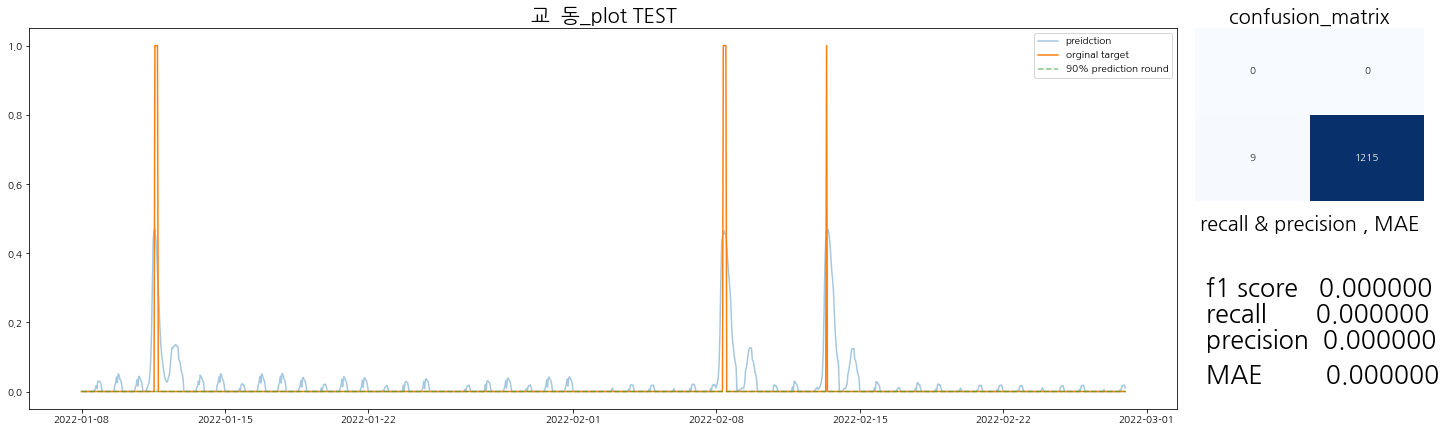

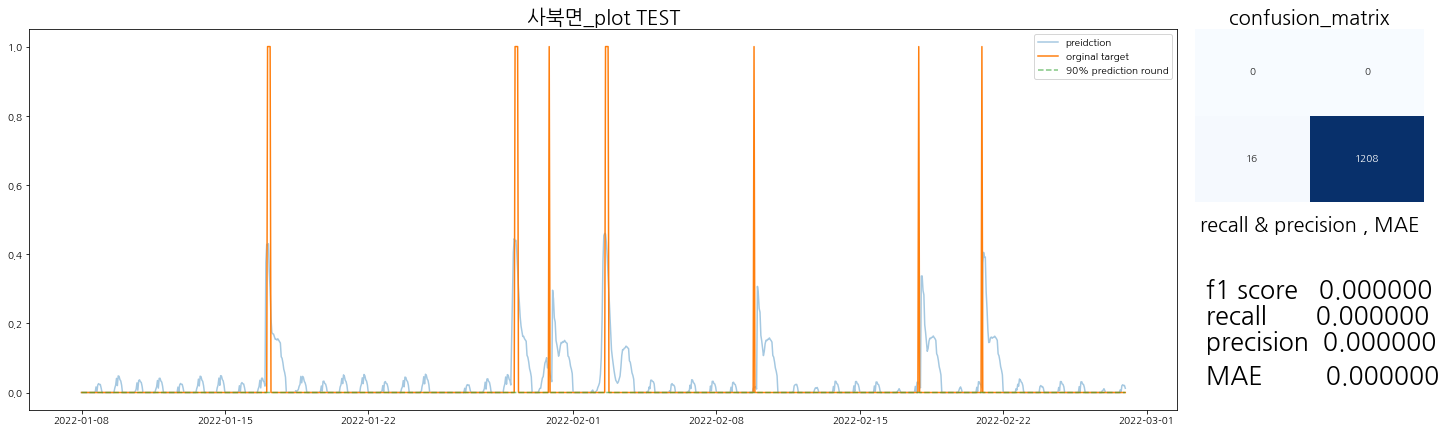

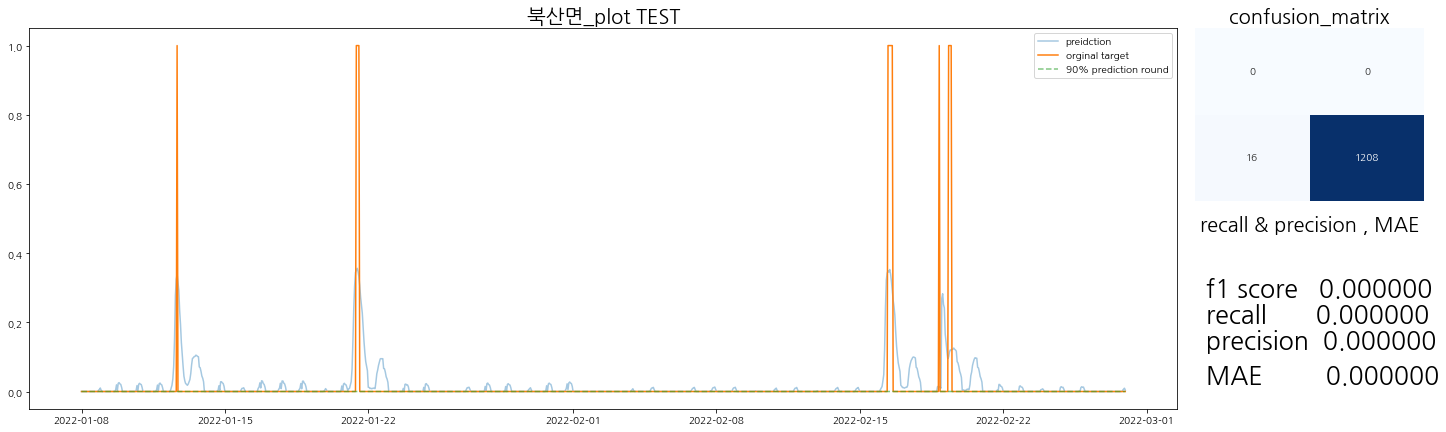

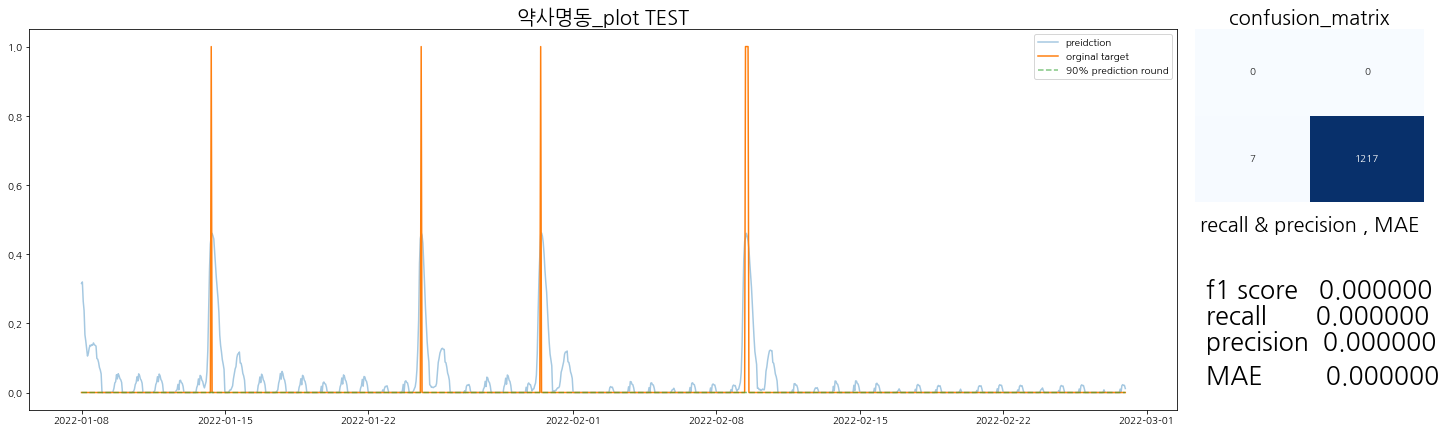

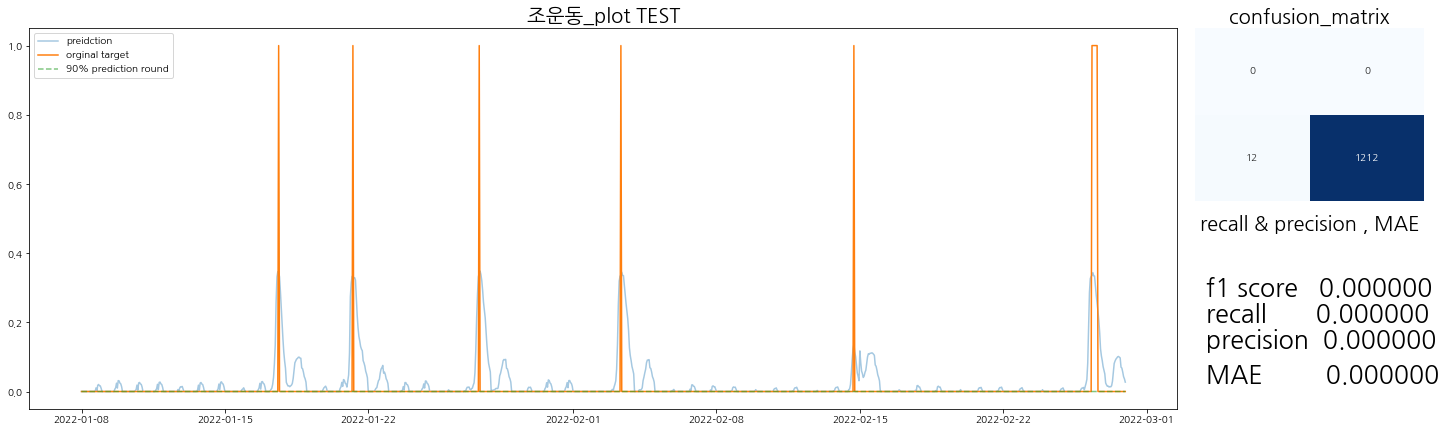

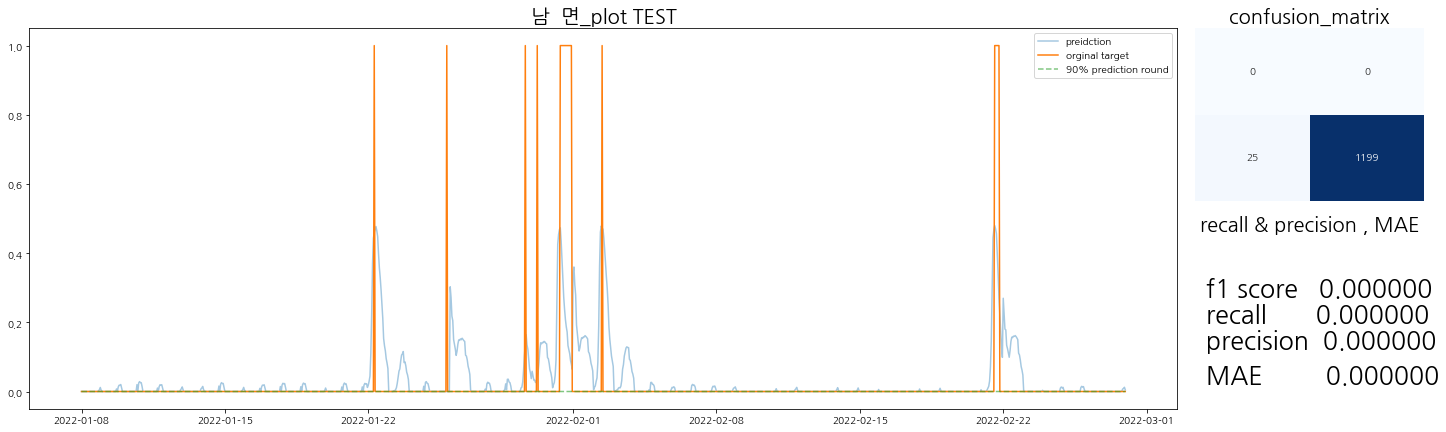

In [24]:
abc = get_f1(training,tft, test_data)
for s_dong in abc['h_dong']:
    confusion_matrix_plot(training, tft ,test_data, s_dong , 'TEST')
    

In [35]:
dong_f1_all(training , tft ,test_data)

0.2962146269753767

In [37]:
abc

,h_dong,f1_score
15,신사우동,0.476923
4,남산면,0.448
13,신동면,0.410256
5,동 면,0.4
10,서 면,0.380952
19,효자1동,0.330882
7,동산면,0.326923
11,석사동,0.324324
18,퇴계동,0.30495
0,강남동,0.284585
